### Flexible Prior-Guided Reconstruction with Kernel Methods
This tutorial demonstrates a flexible framework for kernel expectation maximization (KEM) and a patch-based deep-learned kernel method for prior-guided emission tomography reconstruction. We use PET-guided SPECT reconstruction as an example. The framework can also support other applications, such as MR-guided PET reconstruction, given an appropriate forward model and a spatially aligned prior image.

If you find it is useful, please cite:

H. Wei, L. Livieratos, and A. J. Reader, “PET-Informed Deep-Learned Kernel Method for Theranostic SPECT Reconstruction,” IEEE Transactions on Radiation and Plasma Medical Sciences, early access, 2026, doi: 10.1109/TRPMS.2026.3737413.https://ieeexplore.ieee.org/document/11707312 

L. A. Polson et al., “PyTomography: A python library for medical image reconstruction,” SoftwareX, vol. 29, p. 102020, 2025.

### 1. Load simulated PET image and SPECT data

We load a simulated <sup>68</sup>Ga-DOTATATE PET image and a <sup>177</sup>Lu-DOTATATE SPECT data based on Zubal Phantom. For simplicity, we use the npy file to demonstrate the algorithm. If you have your own simulation or use real data, please refer to SIMIND and DICOM tutorials.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = "../../../data/zubal"

pet_prior = np.load(f"{DATA_DIR}/simulated_Ga_pet_image.npy")
spect_projections = np.load(f"{DATA_DIR}/spect_projections_3d_20m.npy")



### 2. Create a SPECT forward operator and reconstruct SPECT data with MLEM/OSEM. 
(Also, we only use a simple forward operator for demonstration, you can get the metadata easily for real data described in DICOM tutorials)

In [3]:
import torch
import pytomography
from pytomography.metadata.SPECT import SPECTObjectMeta, SPECTProjMeta, SPECTPSFMeta
from pytomography.transforms.SPECT import SPECTAttenuationTransform, SPECTPSFTransform
from pytomography.projectors.SPECT import SPECTSystemMatrix
from pytomography.likelihoods import PoissonLogLikelihood
from pytomography.algorithms import OSEM

pytomography.set_device(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
pytomography.set_dtype(torch.float32)

# Image and acquisition geometry (distances in cm).
object_meta = SPECTObjectMeta(dr=(0.4, 0.4, 0.4), shape=(128, 128, 128))
proj_meta = SPECTProjMeta(
    projection_shape=(128, 128),
    dr=(0.4, 0.4),
    angles=np.linspace(0, 360, 120, endpoint=False),
    radii=np.full(120, 30.0),
)

# Match the attenuation and PSF used to generate the projections.
attenuation_map = torch.as_tensor(
    np.load(f"{DATA_DIR}/spect_attenuation_3d.npy"),
    dtype=pytomography.dtype,
    device=pytomography.device,
)
attenuation = SPECTAttenuationTransform(attenuation_map=attenuation_map)
psf = SPECTPSFTransform(
    psf_meta=SPECTPSFMeta(sigma_fit_params=(0.02, 0.1))
)

system_matrix = SPECTSystemMatrix(
    [attenuation, psf], [], object_meta, proj_meta
)
projections = torch.as_tensor(
    spect_projections,
    dtype=pytomography.dtype,
    device=pytomography.device,
)

mlem = OSEM(PoissonLogLikelihood(system_matrix, projections))
spect_mlem = mlem(n_iters=50, n_subsets=1).detach().cpu().numpy()



### 3. Construct the kernel from PET prior image

The kernel is constructed from the PET prior using the following parameters:
$$
\begin{aligned}
\kappa(\mathbf{f}_j,\mathbf{f}_l,\mathbf{c}_j,\mathbf{c}_l)
&= \exp\left(
-\frac{\|\mathbf{f}_j-\mathbf{f}_l\|^2}{2\sigma_f^2}
\right) \exp\left(
-\frac{\|\mathbf{c}_j-\mathbf{c}_l\|^2}{2\sigma_c^2}
\right).
\end{aligned}
$$
- `k`: Number of k-nearest neighbors.
- `sigmaf`: Bandwidth for standardized PET features.
- `sigmac`: Spatial bandwidth in voxel units.
- `patch`: Side length of the 3D feature patch; `1` uses voxel intensity, while `3` uses a 3 × 3 × 3 patch.
- `local_window`: Side length of the neighborhood search window in local mode.
- `mode`: `"local"` searches within the local window; `"global"` searches across the entire image.

The kernel weights and neighbor indices can be saved as `.npy` files and reused with `ExternalKEMTransform.from_files()`, avoiding repeated kernel construction.

In [5]:
from pytomography.utils.kernel import construct_kernel

weights, indices = construct_kernel(
    pet_prior,
    k=50,
    sigmaf=1.0,
    sigmac=1.0,
    patch=1,
    local_window=9,
    mode="local",
    device="cuda",
    chunk_size=4096,
)

np.save(f"{DATA_DIR}/kernel_weights.npy", weights)
np.save(f"{DATA_DIR}/kernel_indices.npy", indices)

In [6]:
print(weights.shape, indices.shape)

(2097152, 50) (2097152, 50)


### 4. Load the saved kernel and do KEM for SPECT reconstruction

In [7]:
from pytomography.transforms.shared import ExternalKEMTransform
from pytomography.projectors.shared import KEMSystemMatrix
from pytomography.algorithms import KEM

kernel = ExternalKEMTransform.from_files(
    f"{DATA_DIR}/kernel_weights.npy",
    f"{DATA_DIR}/kernel_indices.npy",
)

kem_system_matrix = KEMSystemMatrix(system_matrix, kernel)
kem = KEM(PoissonLogLikelihood(kem_system_matrix, projections))

spect_kem = kem(n_iters=50, n_subsets=1).detach().cpu().numpy()

### A patch-based deep-learned kernel method 
described in H. Wei, L. Livieratos, and A. J. Reader, “PET-Informed Deep-Learned Kernel Method for Theranostic SPECT Reconstruction,” IEEE Transactions on Radiation and Plasma Medical Sciences, early access, 2026, doi: 10.1109/TRPMS.2026.3737413.https://ieeexplore.ieee.org/document/11707312

### Train and construct the deep kernel

A 3D U-Net learns feature vectors from the PET prior. For every voxel in a training patch, we select local neighbors using these features and aggregate their SPECT MLEM values. The network is trained by minimizing the MSE between the resulting patch and the PET patch. 

**Network parameters**
- `base_channels`: U-Net width. Larger values increase model capacity and memory use.
- `feature_channels`: Number of learned features per voxel.

**Training parameters**
- `epochs`: Number of training epochs.
- `patches_per_epoch`: Number of random patches processed per epoch.
- `patch_size`: Side length of each cubic training patch. 
- `chunk_size`: Number of center voxels processed at once. Every voxel in the patch contributes to the loss; smaller chunks reduce memory use.
- `learning_rate`: Adam learning rate.
- `device`: `"cuda"` for GPU or `"cpu"` for CPU.

**Kernel parameters**
- `k`: Number of neighbors retained for each center voxel.
- `local_window`: Side length of the local search window, such as `9`.
- `include_self`: Whether the center voxel can be its own neighbor.

Start with `base_channels=16`, `feature_channels=16`, `patch_size=32`, `k=50`, and `local_window=9`. Use the same kernel parameters during training and export.

After training, call `construct_deep_kernel()` to generate the full-image kernel. Save its weights and indices as `.npy` files, load them with `ExternalKEMTransform.from_files()`, and run KEM using the same SPECT projector and projections as the other methods. The exported kernel remains fixed during reconstruction.

In [10]:
from pytomography.models import UNet3D
from pytomography.utils.deep_kernel import train_deep_kernel, construct_deep_kernel

torch.manual_seed(2026)
model = UNet3D(base_channels=16, feature_channels=16)

deep_params = dict(
    k=50,
    local_window=9,
    include_self=False,
)

history = train_deep_kernel(
    model, pet_prior, spect_mlem,
    epochs=10,
    patches_per_epoch=300,
    patch_size=32,
    chunk_size=51200,
    learning_rate=1e-3,
    device=pytomography.device,
    **deep_params,
)

Epoch 1/10 | MSE: 0.000202
Epoch 2/10 | MSE: 0.000157
Epoch 3/10 | MSE: 0.000144
Epoch 4/10 | MSE: 0.000131
Epoch 5/10 | MSE: 0.000100
Epoch 6/10 | MSE: 0.000107
Epoch 7/10 | MSE: 0.000105
Epoch 8/10 | MSE: 0.000091
Epoch 9/10 | MSE: 0.000096
Epoch 10/10 | MSE: 0.000096


In [11]:
deep_weights, deep_indices = construct_deep_kernel(
    model, pet_prior,
    chunk_size=512,
    device=pytomography.device,
    **deep_params,
)

np.save(f"{DATA_DIR}/deep_kernel_weights.npy", deep_weights)
np.save(f"{DATA_DIR}/deep_kernel_indices.npy", deep_indices)

In [12]:
deep_kernel = ExternalKEMTransform.from_files(
    f"{DATA_DIR}/deep_kernel_weights.npy",
    f"{DATA_DIR}/deep_kernel_indices.npy",
)

deep_system_matrix = KEMSystemMatrix(system_matrix, deep_kernel)
deep_kem = KEM(PoissonLogLikelihood(deep_system_matrix, projections))

spect_deep_kem = deep_kem(n_iters=50, n_subsets=1).detach().cpu().numpy()

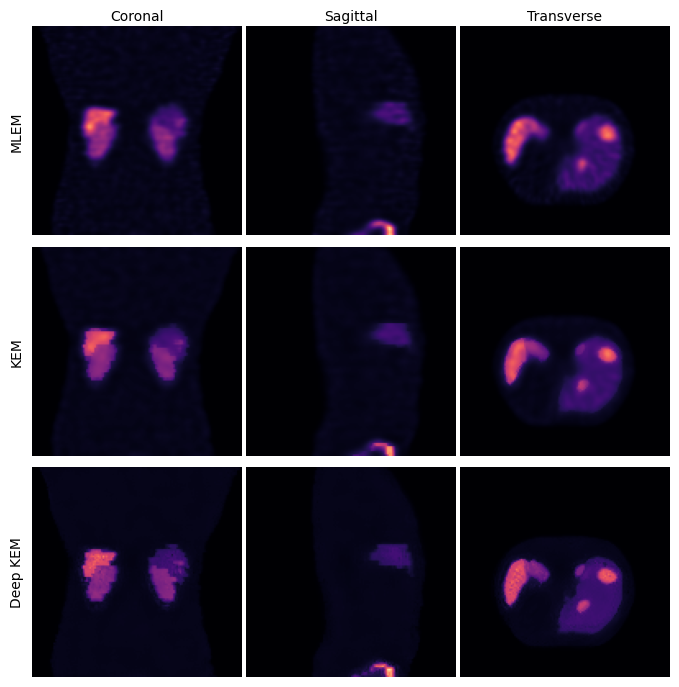

In [15]:
images = [
    (spect_mlem, "MLEM"),
    (spect_kem, "KEM"),
    (spect_deep_kem, "Deep KEM"),
]

vmax = max(volume.max() for volume, _ in images)
fig, axes = plt.subplots(3, 3, figsize=(7, 7))

for row, (volume, name) in enumerate(images):
    slices = [
        volume[:, 60, :].T,
        volume[60, :, :].T,
        volume[:, :, 60].T,
    ]

    for col, (image, plane) in enumerate(zip(
        slices, ["Coronal", "Sagittal", "Transverse"]
    )):
        ax = axes[row, col]
        ax.imshow(image, cmap="magma", origin="upper", vmin=0, vmax=vmax)
        ax.axis("off")

        if row == 0:
            ax.set_title(plane, fontsize=10, pad=4)
        if col == 0:
            ax.text(
                -0.04, 0.5, name, transform=ax.transAxes,
                rotation=90, va="center", ha="right", fontsize=10
            )

plt.subplots_adjust(
    left=0.08, right=0.99, bottom=0.01, top=0.95,
    wspace=0.02, hspace=0.02
)
plt.show()